# Customer Churn Classification Model

### Context:   
    - Customer churn, the rate at which customers cancel their subscriptions, is a vital metric for businesses offering subscription services. Predictive analytics techniques are employed to anticipate which customers are likely to churn, enabling companies to take proactive measures for customer retention.

    - Customer churn is a critical metric because it is less expensive to retain existing customers than it is to acquire new customers.

### Dataset: 
-  This project utilizes the dataset of a dummy company from the Kaggle website <br> 
(https://www.kaggle.com/datasets/harshitstark/dataset/data)

### Objective: 
-  To reduce customer churn, companies need to predict which customers are at high risk of churn.

### Data Mining Algorithms: 
-  Different Classification Algorithms such as Logistic Regression etc <br>

- Variables
    - id: The sequential number assigned to each row in the dataset.
    - CustomerId: A unique identifier for each customer.

    - Surname: The surname of the customer.

    - CreditScore: The credit score of the customer.

    - Geography: The geographical location of the customer (e.g., country or region).

    - Gender: The gender of the customer.

    - Age: The age of the customer.

    - Tenure: The number of years the customer has been with the bank.

    - Balance: The account balance of the customer.

    - NumOfProducts: The number of bank products the customer has.

    - HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).

    - IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).

    - EstimatedSalary: The estimated salary of the customer.

    - Exited: Indicates whether the customer has exited the bank (binary: yes/no).

## CONTENT SUMMARY
1) Importing the libraries
2) Loading the data
3) EDA + Data Cleaning/Pre-processing
4) Data Transformation
5) Model Building
6) Understanding the Model
7) Conclusion


### Importing the libraries
<a id='import-libt'></a>

In [634]:
#Standard Libraries

import sys
import pandas as pd 
import numpy as np 
import scipy as sp
import IPython
from IPython import display

import sklearn

#misc libraries
import random
import time

#ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [635]:
#Modelling Libraries

#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from sklearn.metrics import make_scorer, accuracy_score,roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score,auc,roc_curve,ConfusionMatrixDisplay
from xgboost import XGBClassifier

#Common Model Helpers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler,RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn import metrics

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
from pandas.plotting import scatter_matrix

#Configure Visualization Defaults
#%matplotlib inline = show plots in Jupyter Notebook browser
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style('white')
# plt.rcParams['figure.figsize'] = 8,4
pd.set_option("display.max_columns", 999)

In [636]:
#importing different classification Algorithms

from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score,StratifiedKFold
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

### Loading the data

In [637]:
path = r"C:\Users\DELL\Downloads\Personal_Projects\Classification_Customer_Churn"

In [638]:
data = pd.read_csv(path + "\\data\\train.csv")

### EDA + Data Cleaning/Pre-processing
- Data needs to undergo iterations of pre-processing and EDA. As such, the following shall be implemented in no particular order:
    - Getting the list of columns and the original shape of dataframe
    - Describing the statistical summary of numeric columns 
    - Checking for columns with unique values
    - Checking for NA and NAN values
    - Removing BLANK Rows, REDUNDANT and UNUSABLE Columns
    - Changing data types
    - Treating columns with ordinal values
    - Dropping unnecessary rows/columns
    - Imputation of missing data if necessary

- Initial Exploratory Data Analysis (EDA)

In [639]:
#Check a sample of the dataset for initial exploration
data.head(20)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [640]:
#Check Shape of Dataset
print(f"Number of ROWS: {data.shape[0]}\nNumber of COLUMNS: {data.shape[1]}")

Number of ROWS: 165034
Number of COLUMNS: 14


In [641]:
#Create a list of columns
data.columns.to_list()

['id',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

- After checking the shape and variables of our dataset, we have to check the summary statistics, unique values, as well as data types. This will help us determine what types of data cleaning we need to implement later on. 

In [642]:
#Initial checking of data info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 20.4 MB


- Whole Dataset
    - Check the whole dataset first

In [643]:
#Get Summary Stats of Numerical Columns
#By default, .describe() shows summary stats for numeric columns only
data.describe().T.sort_values(by='count',ascending=True)


,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


In [644]:
#Get Summary Stats of Categorical Columns
data.describe(exclude=np.number).T.sort_values(by='unique',ascending=False)

,count,unique,top,freq
Surname,165034,2797,Hsia,2456
Geography,165034,3,France,94215
Gender,165034,2,Male,93150


- Then check the filtered dataset (you can check for those churn and non-churn to have a profle of the customers)
    - Churn customers

In [645]:
#Get Summary Stats of Numerical Columns
#By default, .describe() shows summary stats for numeric columns only
data_churn = data.loc[data['Exited']==1]
data_churn.describe().T.sort_values(by='count',ascending=True)

,count,mean,std,min,25%,50%,75%,max
id,34921.0,8.274752e+04,47538.333677,5.00,41656.00,82515.00,124032.00,165033.00
CustomerId,34921.0,1.569063e+07,71864.865084,15565706.00,15631512.00,15687765.00,15756056.00,15815690.00
CreditScore,34921.0,6.522205e+02,81.136331,350.00,593.00,651.00,708.00,850.00
Age,34921.0,4.395848e+01,9.004380,18.00,38.00,44.00,50.00,92.00
Tenure,34921.0,4.914378e+00,2.826564,0.00,3.00,5.00,7.00,10.00
Balance,34921.0,7.120998e+04,62646.691947,0.00,0.00,98955.87,125437.14,238387.56
NumOfProducts,34921.0,1.327854e+00,0.661912,1.00,1.00,1.00,1.00,4.00
HasCrCard,34921.0,7.355459e-01,0.441048,0.00,0.00,1.00,1.00,1.00
IsActiveMember,34921.0,2.948656e-01,0.455989,0.00,0.00,0.00,1.00,1.00
EstimatedSalary,34921.0,1.144025e+05,50542.030878,11.58,74965.44,120892.96,158750.53,199992.48


In [646]:
#Get Summary Stats of Categorical Columns
data_churn.describe(exclude=np.number).T.sort_values(by='unique',ascending=False)

,count,unique,top,freq
Surname,34921,2185,Hsia,514
Geography,34921,3,France,15572
Gender,34921,2,Female,20105


- Then check the filtered dataset (you can check for those churn and non-churn to have a profle of the customers)
    - Non-Churn customers

In [647]:
#Get Summary Stats of Numerical Columns
#By default, .describe() shows summary stats for numeric columns only
data_non_churn = data.loc[data['Exited']==0]
data_non_churn.describe().T.sort_values(by='count',ascending=True)

,count,mean,std,min,25%,50%,75%,max
id,130113.0,8.245450e+04,47668.960691,0.00,41168.00,82519.00,123697.00,165032.00
CustomerId,130113.0,1.569237e+07,71267.734570,15565701.00,15633854.00,15690670.00,15756880.00,15815690.00
CreditScore,130113.0,6.575907e+02,79.785902,350.00,599.00,662.00,711.00,850.00
Age,130113.0,3.656048e+01,8.147944,18.00,31.00,36.00,40.00,92.00
Tenure,130113.0,5.048796e+00,2.799985,0.00,3.00,5.00,7.00,10.00
Balance,130113.0,5.125581e+04,62189.978970,0.00,0.00,0.00,116858.66,250898.09
NumOfProducts,130113.0,1.615273e+00,0.494632,1.00,1.00,2.00,2.00,4.00
HasCrCard,130113.0,7.588942e-01,0.427756,0.00,1.00,1.00,1.00,1.00
IsActiveMember,130113.0,5.522277e-01,0.497267,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,130113.0,1.120843e+05,50214.655044,11.58,74425.41,116977.89,153727.32,199992.48


In [648]:
#Get Summary Stats of Categorical Columns
data_non_churn.describe(exclude=np.number).T.sort_values(by='unique',ascending=False)

,count,unique,top,freq
Surname,130113,2724,T'ien,1945
Geography,130113,3,France,78643
Gender,130113,2,Male,78334


In [649]:
#Check for the unique elements on each column
for col in data.columns:
    print("\n",'==',col,'==')
    print(data[col].unique())


 == id ==
[     0      1      2 ... 165031 165032 165033]

 == CustomerId ==
[15674932 15749177 15694510 ... 15673571 15692656 15815050]

 == Surname ==
<ArrowStringArray>
['Okwudilichukwu',  'Okwudiliolisa',          'Hsueh',            'Kao',
      'Chiemenam',       'Genovese',         'Ch'ang',    'Chukwuebuka',
          'Manna',       'Cattaneo',
 ...
       'Galloway',          'Batty',        'Buckner',       'Morphett',
       'Humffray',      'Christmas',        'Ah Mouy',         'Aliyev',
         'McMinn',         'Elkins']
Length: 2797, dtype: str

 == CreditScore ==
[668 627 678 581 716 588 593 676 583 599 687 759 681 703 549 602 636 645
 559 773 554 553 714 616 586 785 834 632 746 797 753 749 413 611 752 551
 747 683 684 696 591 488 685 579 607 742 677 461 634 647 577 809 686 633
 494 699 663 756 648 563 682 620 721 652 535 584 701 640 711 707 631 637
 622 775 817 592 743 726 431 571 659 639 618 722 712 672 804 730 506 569
 558 507 594 796 615 619 471 434 706 758 762 6

In [650]:
#Check for the missing/null values
def check_null_values(df, rate=0):
    '''a function to show null values with percentage'''
    nv = pd.concat([df.isnull().sum(), 100 * df.isnull().sum()/df.shape[0]],axis=1).rename(
        columns={0:'Missing_Rows', 1:'Percentage_Missing (%)'})
    return nv[nv['Percentage_Missing (%)']>rate].sort_values('Percentage_Missing (%)', ascending=False)

In [651]:
null_columns = pd.DataFrame(check_null_values(data))
null_columns

,Missing_Rows,Percentage_Missing (%)


In [652]:
null_columns_list = null_columns.T.columns.to_list()
null_columns_list

[]

- Some initial observations:

    - ```CustomerId``` and ```Surname``` should be dropped since they are not necessary variables

    <!-- - ```MaritalStatus``` has a lot of 'Unknowns' which needs imputation -->
    

- Data Cleaning/Pre-processing

    - After our findings during Initial EDA, we can now perform data cleaning/pre-processing to fix the issues in our dataset and prepare it in a form ready for modelling

In [653]:
#Create copy of original dataset as backup
data_copy = data.copy()
data_for_cleaning = data_copy.reset_index(drop=True)
data_for_cleaning.head(10)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [654]:
#Drop Unnecessary columns 
# data_cleaned = data_for_cleaning.drop(
#     columns=[
#         'id',
#         'CustomerId', # not needed
#         'Surname'
#         # 'TotalCharges',# contains too many unique which is bad for dummy variable creation
#         # 'NotNewCellphoneUser' #redundant column 
# ])
# 1. Move identifier columns to the index

data_cleaned = data_for_cleaning.copy()
data_cleaned['Churn'] = data_cleaned['Exited']
data_cleaned.set_index(['id','CustomerId','Surname','Churn'], inplace=True)
data_cleaned.head(100)

,,,,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,CustomerId,Surname,Churn,,,,,,,,,,,
0,15674932,Okwudilichukwu,0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,0,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,0,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,15741417,Kao,0,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,15766172,Chiemenam,0,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,15791534,Scott,0,588,Germany,Male,30.0,10,126683.40,1,1.0,1.0,131636.55,0
96,15671139,Shih,1,659,Spain,Female,39.0,0,107042.74,1,1.0,0.0,102284.20,1
97,15576935,Ampt,0,743,Spain,Male,43.0,2,161807.18,2,0.0,1.0,93228.86,0


In [655]:
#Changing Data types
#Check first the intial data type
data_cleaned.info()

<class 'pandas.DataFrame'>
MultiIndex: 165034 entries, (np.int64(0), np.int64(15674932), 'Okwudilichukwu', np.int64(0)) to (np.int64(165033), np.int64(15732798), 'Ulyanov', np.int64(1))
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  str    
 2   Gender           165034 non-null  str    
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Exited           165034 non-null  int64  
dtypes: float64(5), int64(4), str(2)
memory usage: 18.5 MB


In [656]:
# data_cleaned['Churn'] = np.where(data_cleaned['Churn'] =='No' ,0,1).astype('int64')
data_cleaned = data_cleaned.rename(columns={'Exited':'Churn'})


In [657]:
#Checking if the data types are now correct
data_cleaned.info()

<class 'pandas.DataFrame'>
MultiIndex: 165034 entries, (np.int64(0), np.int64(15674932), 'Okwudilichukwu', np.int64(0)) to (np.int64(165033), np.int64(15732798), 'Ulyanov', np.int64(1))
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  str    
 2   Gender           165034 non-null  str    
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Churn            165034 non-null  int64  
dtypes: float64(5), int64(4), str(2)
memory usage: 18.5 MB


- Separate Numerical from Categorical columns

In [658]:
#Select Categorical Columns
categorical = data_cleaned.select_dtypes(include=['object'])
categorical_cols = list(categorical.columns)
categorical.shape

(165034, 2)

In [659]:
for col in categorical.columns:
    print("\n",'==',col,'==')
    print(categorical[col].unique())


 == Geography ==
<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

 == Gender ==
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str


In [660]:
for col in categorical:
    print("=="*20,'\n',data_cleaned[col].value_counts(),'\n')

 Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64 

 Gender
Male      93150
Female    71884
Name: count, dtype: int64 



In [661]:
#Select Numerical Columns
numerical = data_cleaned.select_dtypes(include=['int32','int64','float64','uint8'])
# numerical = numerical.drop(columns=['loan_condition_cat'])
numerical_cols = list(numerical.columns)
numerical.shape

(165034, 9)

In [662]:
for col in numerical.columns:
    print("\n",'==',col,'==')
    print(numerical[col].unique())# 


 == CreditScore ==
[668 627 678 581 716 588 593 676 583 599 687 759 681 703 549 602 636 645
 559 773 554 553 714 616 586 785 834 632 746 797 753 749 413 611 752 551
 747 683 684 696 591 488 685 579 607 742 677 461 634 647 577 809 686 633
 494 699 663 756 648 563 682 620 721 652 535 584 701 640 711 707 631 637
 622 775 817 592 743 726 431 571 659 639 618 722 712 672 804 730 506 569
 558 507 594 796 615 619 471 434 706 758 762 635 630 709 661 644 731 748
 613 727 649 835 587 765 667 479 850 674 715 655 723 590 539 788 359 660
 517 740 694 578 610 718 705 542 624 601 625 596 770 695 662 567 744 595
 736 724 751 646 670 741 543 754 691 641 679 523 621 589 582 642 600 732
 698 469 525 520 470 692 532 651 605 792 638 671 540 821 822 557 689 521
 604 628 568 597 556 449 717 713 536 657 452 719 564 484 816 825 512 531
 818 745 527 774 738 547 708 603 725 477 680 443 562 580 729 710 574 447
 497 656 550 766 728 653 537 609 704 772 781 697 428 757 666 522 453 643
 612 501 585 735 510 544 565 75

In [663]:
for col in numerical:
    print("=="*20,'\n',data_cleaned[col].value_counts(),'\n')

 CreditScore
850    2532
678    2299
684    1718
667    1658
705    1605
       ... 
419       1
386       1
358       1
423       1
373       1
Name: count, Length: 457, dtype: int64 

 Age
37.00    9255
38.00    9246
35.00    9118
34.00    8625
36.00    8556
         ... 
84.00       4
83.00       3
85.00       3
36.44       1
32.34       1
Name: count, Length: 71, dtype: int64 

 Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64 

 Balance
0.00         89648
124577.33       88
127864.40       64
122314.50       63
129855.32       59
             ...  
140791.57        1
118022.74        1
117412.34        1
134937.10        1
110993.29        1
Name: count, Length: 30075, dtype: int64 

 NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64 

 HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64 

 IsActiveMember
0.0    82885
1.0

In [664]:
#Check distributions for all numeric variables
#Do this to have an idea what kind of imputation to use 
# data_cleaned[numerical_cols].hist(figsize=(20,15));

In [665]:
data_cleaned.info()

<class 'pandas.DataFrame'>
MultiIndex: 165034 entries, (np.int64(0), np.int64(15674932), 'Okwudilichukwu', np.int64(0)) to (np.int64(165033), np.int64(15732798), 'Ulyanov', np.int64(1))
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  str    
 2   Gender           165034 non-null  str    
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Churn            165034 non-null  int64  
dtypes: float64(5), int64(4), str(2)
memory usage: 18.5 MB


In [666]:
check_null_values(data_cleaned)

,Missing_Rows,Percentage_Missing (%)


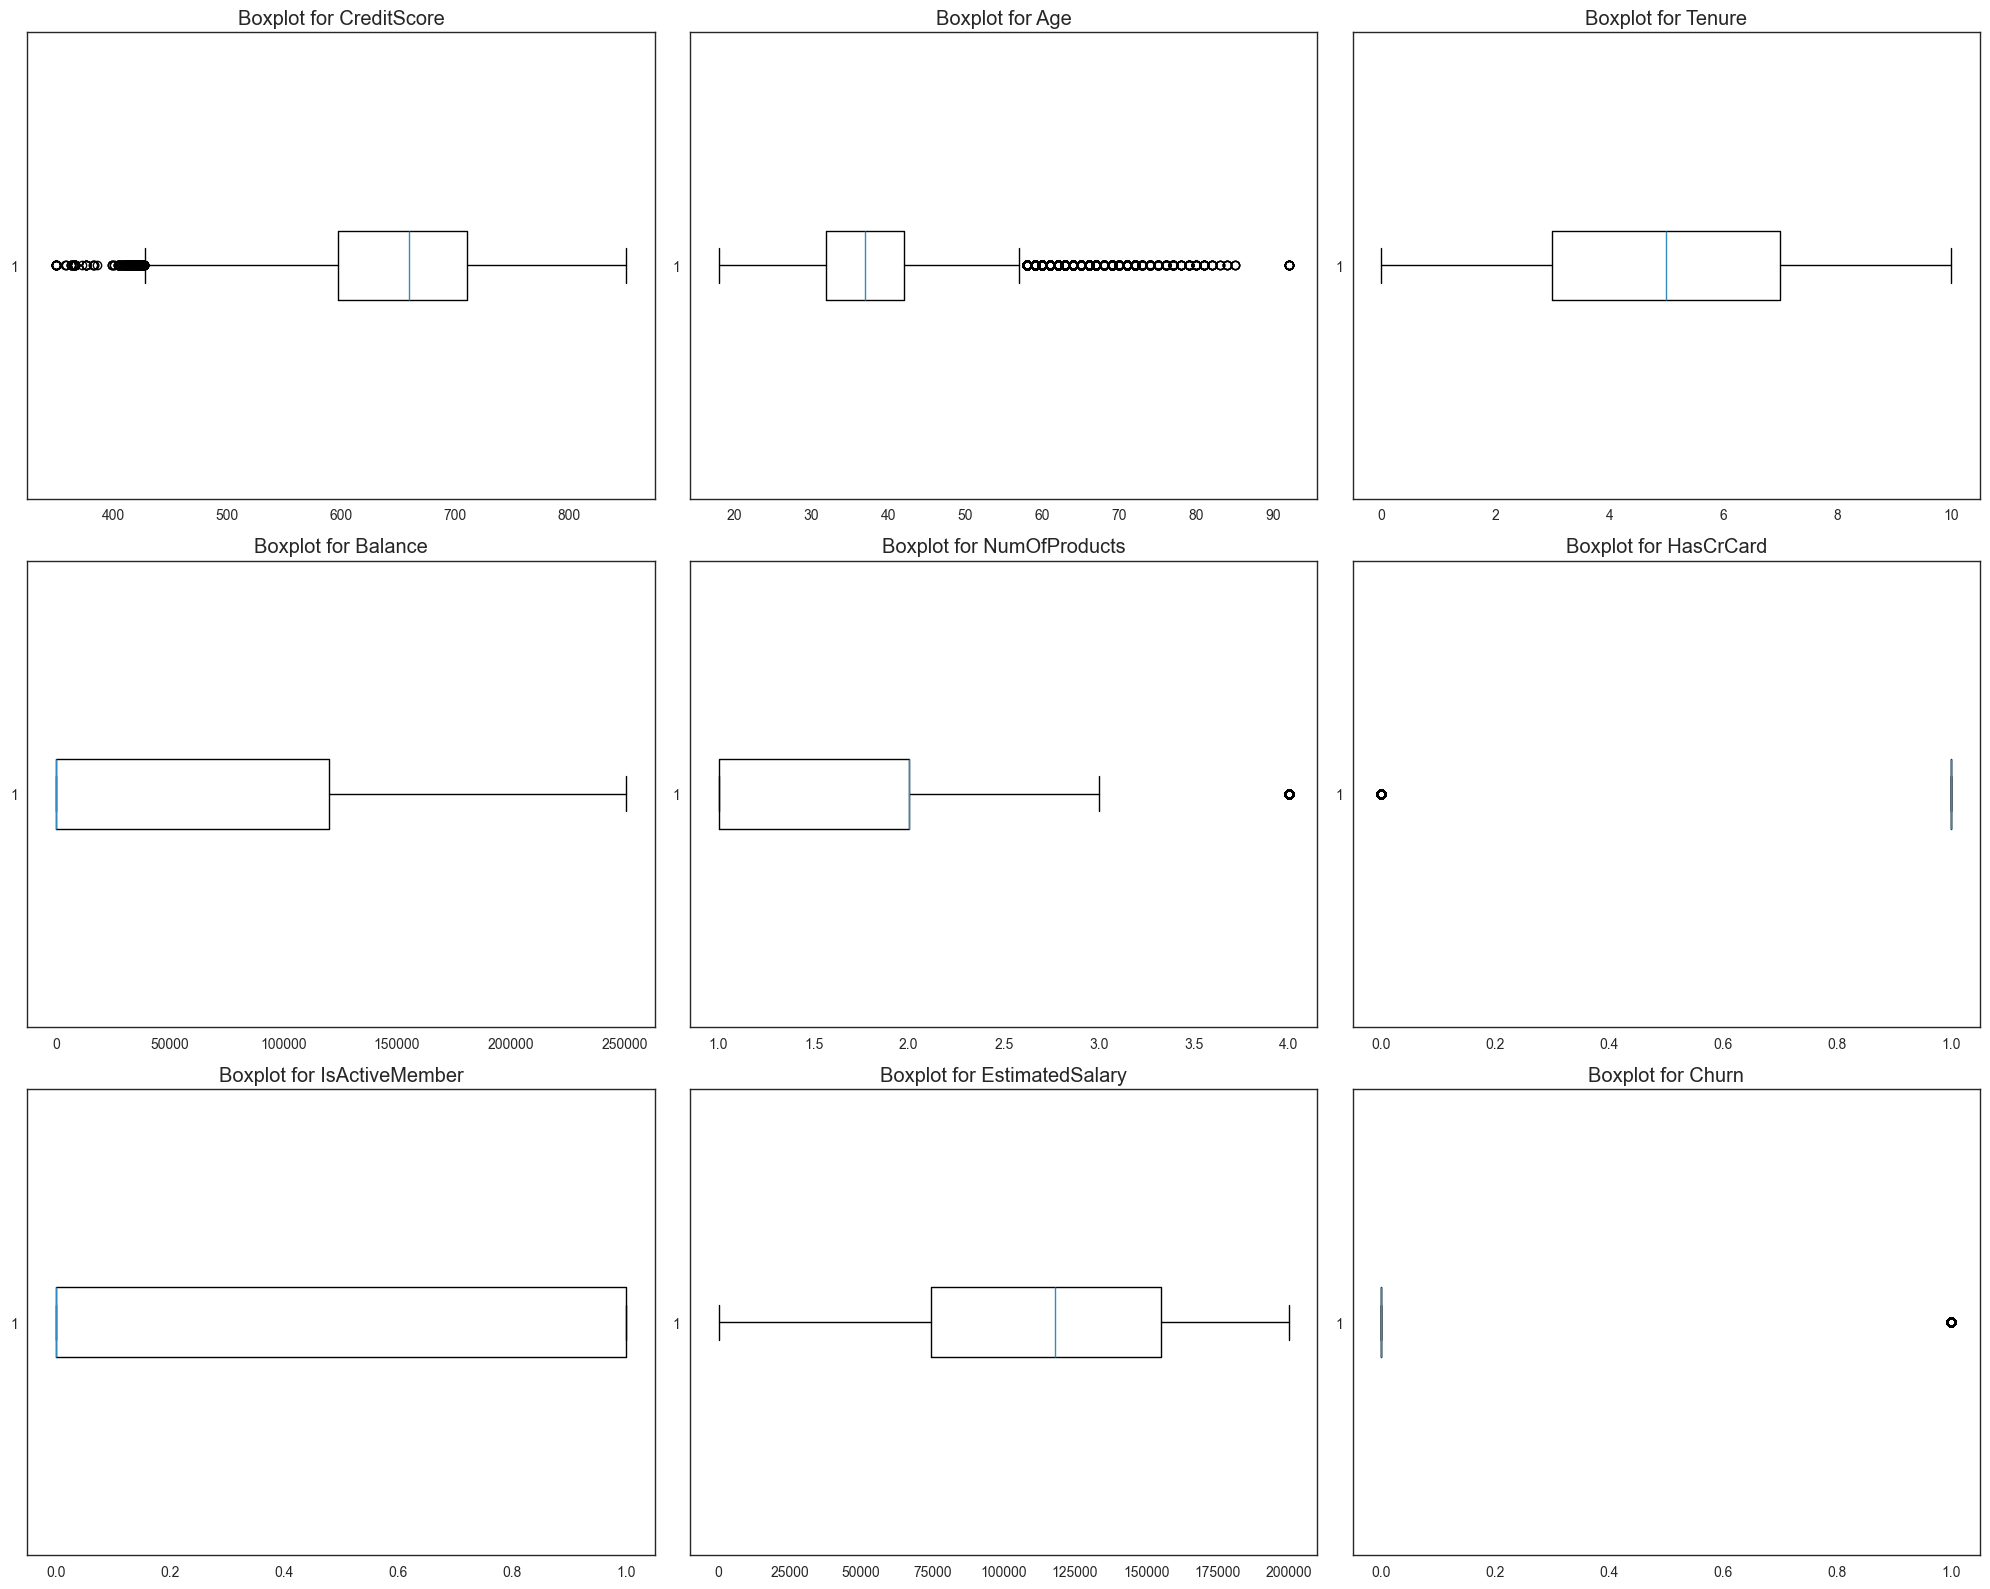

In [667]:
# for col in data_final[numerical_cols]:
#     sns.boxplot(data=data_final,x=col)
#     plt.title("Boxplot of" + str(col)) 

import math

# Example list of numerical variables
numerical_vars = numerical_cols
data = data_cleaned.copy()
# Calculate the optimal number of columns (assuming you want roughly square subplots)
num_vars = len(numerical_vars)
cols = int(math.ceil(math.sqrt(num_vars)))  # Use math.ceil to round up for uneven numbers
rows = math.ceil(num_vars / cols)  # Calculate rows based on columns

# Create the figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 16))  # Adjust figsize for better visualization

# Counter for current subplot index
plot_index = 0

# Loop through each variable name
for var_name in numerical_vars:
  # Check if the variable exists in the dataframe
  if var_name in data.columns:
    # Select the specific column
    var_data = data[var_name]

    # Access current subplot using plot_index
    ax = axes.flat[plot_index]  # Use axes.flat to access subplots as a 1D array

    # Create boxplot on current subplot
    ax.boxplot(var_data,vert=False)
    ax.set_title(f"Boxplot for {var_name}")

    # Increment plot index for next subplot
    plot_index += 1
  else:
    print(f"Warning: Column '{var_name}' not found in data")

# Adjust layout (optional)
plt.tight_layout()

# Display the figure with all subplots
plt.show()


In [668]:
for col in numerical_cols:
    p75 = data_cleaned[data_cleaned[col] > 0][col].quantile(0.75)
    p25 = data_cleaned[data_cleaned[col] > 0][col].quantile(0.25)
    iqr = p75 - p25
    upper_limit = p75 + (1.5 * iqr)
    print('============\n{} with \n Upper Limit {:6.1f},\n P75 {:6.1f},\n IQR(P50) {} \n P25 {:6.1f},\n Outlier Records {} \n============'.format(col, upper_limit, p75,iqr, p25, data_cleaned[data_cleaned[col] > upper_limit]['Churn'].count()))
    data_cleaned[col] = np.where (data_cleaned[col] > upper_limit, upper_limit, data_cleaned[col])

CreditScore with 
 Upper Limit  879.5,
 P75  710.0,
 IQR(P50) 113.0 
 P25  597.0,
 Outlier Records 0 
Age with 
 Upper Limit   57.0,
 P75   42.0,
 IQR(P50) 10.0 
 P25   32.0,
 Outlier Records 6394 
Tenure with 
 Upper Limit   15.5,
 P75    8.0,
 IQR(P50) 5.0 
 P25    3.0,
 Outlier Records 0 
Balance with 
 Upper Limit 186618.0,
 P75 137781.6,
 IQR(P50) 32557.539999999994 
 P25 105224.1,
 Outlier Records 361 
NumOfProducts with 
 Upper Limit    3.5,
 P75    2.0,
 IQR(P50) 1.0 
 P25    1.0,
 Outlier Records 475 
HasCrCard with 
 Upper Limit    1.0,
 P75    1.0,
 IQR(P50) 0.0 
 P25    1.0,
 Outlier Records 0 
IsActiveMember with 
 Upper Limit    1.0,
 P75    1.0,
 IQR(P50) 0.0 
 P25    1.0,
 Outlier Records 0 
EstimatedSalary with 
 Upper Limit 275924.8,
 P75 155152.5,
 IQR(P50) 80514.89749999999 
 P25 74637.6,
 Outlier Records 0 
Churn with 
 Upper Limit    1.0,
 P75    1.0,
 IQR(P50) 0.0 
 P25    1.0,
 Outlier Records 0 


In [669]:
#Use for small datasets or if applicable
# sns.pairplot(data_cleaned[numerical_cols],hue='Churn') 


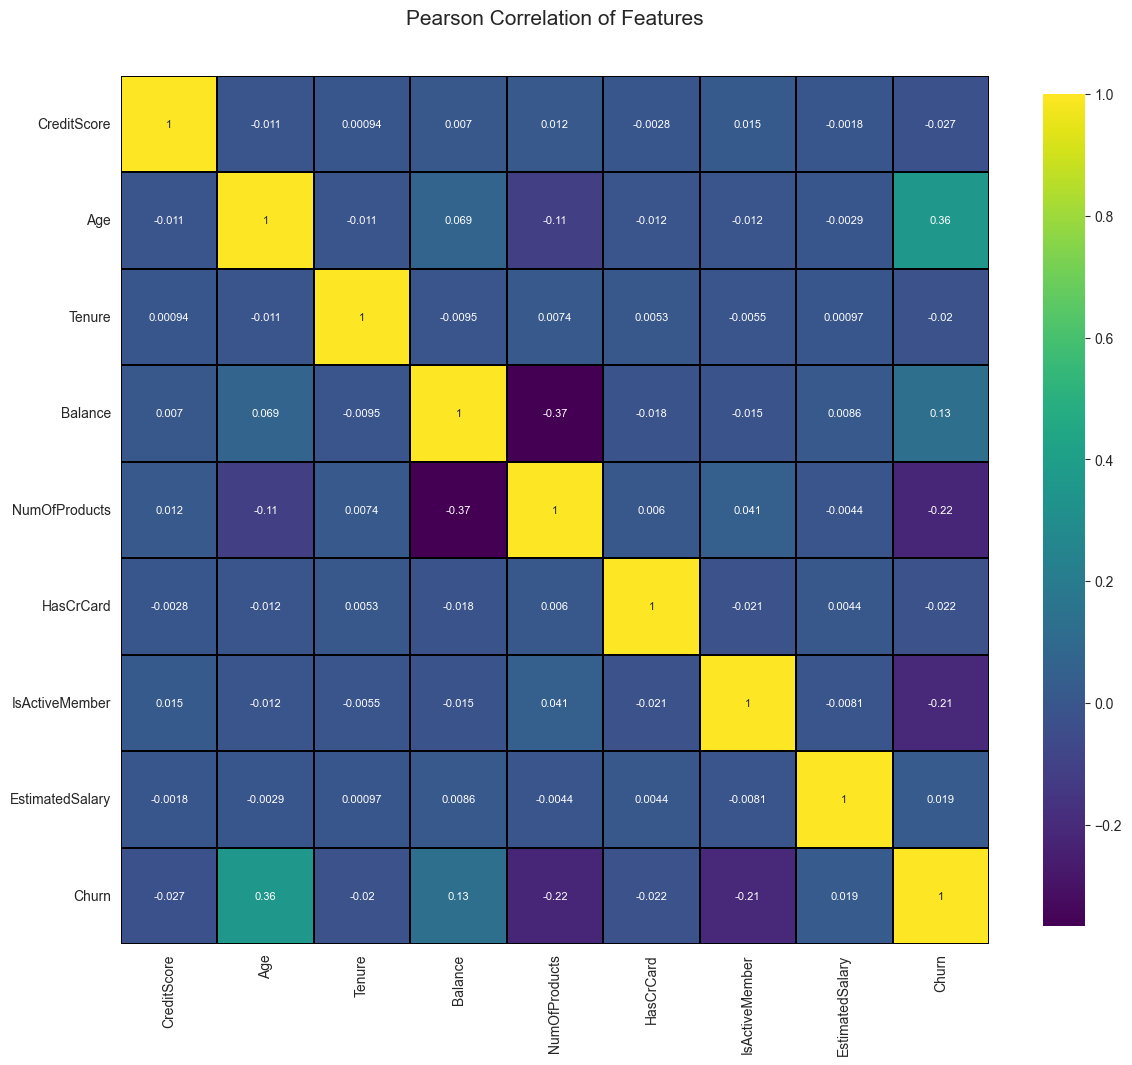

In [670]:
#correlation heatmap of dataset - Use for regression
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = "viridis"#sns.diverging_palette(220, 10, as_cmap = True)
    df = df.select_dtypes(include=[np.number]) #to filter only the numerical columns
    # df = df.iloc[:,:10]
    _ = sns.heatmap(
        df.corr(), 
        cmap = colormap,
        square=True, 
        cbar_kws={'shrink':.9 }, 
        ax=ax,
        annot=True, 
        linewidths=0.1,vmax=1.0, linecolor='black',
        annot_kws={'fontsize':8 }
    )
    
    plt.title('Pearson Correlation of Features', y=1.05, size=15)

correlation_heatmap(data_cleaned)

<a id='data-transform'></a>
### Data Transformation
After the data has completed the pre-processing and EDA stage, the following data transformation will be performed:

1. Encoding Categorical Variables 
2. Feature Scaling

[Back to top](#back-to-top) <br>

In [671]:
#Mapping Yes/No Columns to 0 and 1
for col in data_cleaned[categorical_cols].columns:
    if len(data_cleaned[col].unique()) == 2 and 'No' in data_cleaned[col].to_list():
        try:    
            data_cleaned[col] = np.where(data_cleaned[col] =='No' ,0,1).astype('int64')
        except:
            data_cleaned[col] = np.where(data_cleaned[col] =='Unknown' ,0,1).astype('int64')
        finally:
            pass

        # print(col)
    

In [672]:
for col in data_cleaned[categorical_cols]:
    print("=="*20,'\n',data_cleaned[col].value_counts(),'\n')

 Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64 

 Gender
Male      93150
Female    71884
Name: count, dtype: int64 



In [673]:
#ONE HOT ENCODING/PD GET DUMMIES
data_final = pd.get_dummies(data = data_cleaned, columns = list(data_cleaned.select_dtypes(include=['object'])))

In [674]:
data_final.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Churn', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='str')

In [675]:
data_final.head()

,,,,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,CustomerId,Surname,Churn,,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,0,668.0,33.0,3.0,0.00,2.0,1.0,0.0,181449.97,0.0,True,False,False,False,True
1,15749177,Okwudiliolisa,0,627.0,33.0,1.0,0.00,2.0,1.0,1.0,49503.50,0.0,True,False,False,False,True
2,15694510,Hsueh,0,678.0,40.0,10.0,0.00,2.0,1.0,0.0,184866.69,0.0,True,False,False,False,True
3,15741417,Kao,0,581.0,34.0,2.0,148882.54,1.0,1.0,1.0,84560.88,0.0,True,False,False,False,True
4,15766172,Chiemenam,0,716.0,33.0,5.0,0.00,2.0,1.0,1.0,15068.83,0.0,False,False,True,False,True


In [676]:
#Separate X(independent Variables) and Y(target/dependent variable)
X = data_final.drop(columns=['Churn'])
y = data_final['Churn']

In [677]:
X.head()

,,,,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,CustomerId,Surname,Churn,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,0,668.0,33.0,3.0,0.00,2.0,1.0,0.0,181449.97,True,False,False,False,True
1,15749177,Okwudiliolisa,0,627.0,33.0,1.0,0.00,2.0,1.0,1.0,49503.50,True,False,False,False,True
2,15694510,Hsueh,0,678.0,40.0,10.0,0.00,2.0,1.0,0.0,184866.69,True,False,False,False,True
3,15741417,Kao,0,581.0,34.0,2.0,148882.54,1.0,1.0,1.0,84560.88,True,False,False,False,True
4,15766172,Chiemenam,0,716.0,33.0,5.0,0.00,2.0,1.0,1.0,15068.83,False,False,True,False,True


<Axes: xlabel='Churn', ylabel='count'>

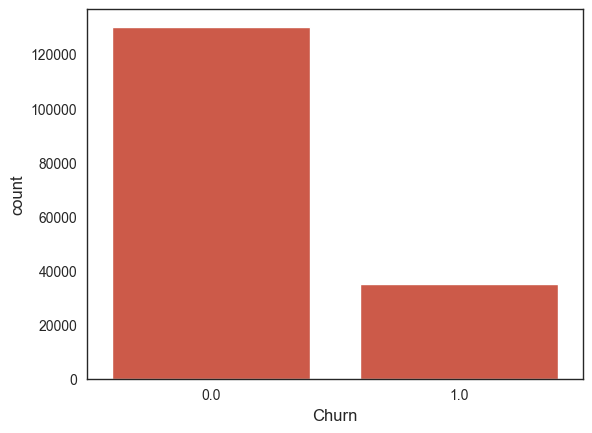

In [678]:
sns.countplot(data=data_final, x='Churn',linewidth=1)

In [679]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42,stratify=y) 

In [680]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(132027, 13) (132027,) (33007, 13) (33007,)


In [681]:
# #FEATURE SCALING
# # scaler = MinMaxScaler()
# scaler = StandardScaler()
scaler = RobustScaler()

# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_ros), columns = X_train_ros.columns)
# X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

# Extract index and columns, then scale the data
X_train_scaled_idx = X_train.index
X_train_scaled_cols = X_train.columns
scaled_values = scaler.fit_transform(X_train)

X_test_scaled_idx = X_test.index
X_test_scaled_cols = X_test.columns
scaled_values2 = scaler.transform(X_test)

# Rebuild the DataFrame while keeping the index
X_train_scaled = pd.DataFrame(scaled_values, index=X_train_scaled_idx, columns=X_train_scaled_cols)
X_test_scaled = pd.DataFrame(scaled_values2, index=X_test_scaled_idx, columns=X_test_scaled_cols)



In [682]:
# from imblearn.over_sampling import RandomOverSampler,SMOTE,ADASYN
# from imblearn.combine import SMOTEENN, SMOTETomek
# from imblearn.under_sampling import NearMiss


# # Perform random oversampling
# # ros = RandomOverSampler(random_state=42)
# # X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# # us = NearMiss(version=3)
# sm = SMOTE(sampling_strategy='minority',random_state=42)
# X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)
# # X_train, y_train = sm.fit_resample(X_train, y_train)
# # X_train_ros, y_train_ros = sm.fit_resample(X_train, y_train)

In [683]:
print(X_train_scaled.shape,y_train.shape)

(132027, 13) (132027,)


In [684]:
print(X_train_scaled.shape,X_test_scaled.shape)

(132027, 13) (33007, 13)


<a id='classification'></a>
### Model Building (Classification)
[Back to top](#back-to-top) <br>

In [685]:
def conf_matrix(actual, predicted, name):
    cm = confusion_matrix(actual, predicted)
    sns.heatmap(cm, xticklabels=['predicted_negative', 'predicted_positive'], 
                yticklabels=['actual_negative', 'actual_positive'], annot=True,
                fmt='d', annot_kws={'fontsize':20}, cmap="viridis")
    plt.title('Confusion Matrix for ' + str(name)); 
    plt.figure()
    plt.rcParams['figure.dpi']=100
    plt.show()
    return cm

In [686]:
def plot_roc(actual, predicted, model_name):
    
    fpr, tpr, thr = roc_curve(actual, predicted,pos_label=1)
    # fig, ax = plt.subplots(figsize=(8, 8))
    plt.plot(fpr, tpr, 'k-',label=f"{model_name} (AUC = {roc_auc_score(actual,predicted)*100:.2f}%)")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=.5)  # roc curve for random model
    # ax.grid(True)
    plt.style.use('ggplot')
    plt.title('ROC Curve(test) for ' + str(model_name))
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.legend(loc='best')
    # x label
    plt.xlabel('False Positive Rate')
    # y label
    plt.ylabel('True Positive rate')
    # plt.rcParams['figure.dpi']=100
    plt.show()
    

### Feature Selection

In [687]:
# instantiate model
# model = RandomForestClassifier(n_estimators=100, random_state=0)
# # select features
# selector = SequentialFeatureSelector(estimator=model, n_features_to_select=10, direction='backward', cv=2)
# selector.fit_transform(X_train_scaled,y_train)
# # check names of features selected
# selected_features = np.array(X_train_scaled.columns)
# selected_features[selector.get_support()]

In [688]:
# from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif

# # select top 2 features using chi2
# selector = SelectKBest(chi2, k=2)
# X_new = selector.fit_transform(X, y)
# print(X_new)

# select top 2 features using f_classif
# selector = SelectKBest(f_classif, k=2)
# X_new = selector.fit_transform(X, y)
# print(X_new)

# # select top 2 features using mutual_info_classif
# selector = SelectKBest(mutual_info_classif, k=10)
# selector.fit_transform(X_train_scaled, y_train)
# selected_features = selector.get_feature_names_out()
# print(selected_features)

In [689]:
# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# # clf.fit(X_train_scaled, y_train)

# X_train_random = X_train_scaled.copy()
# X_train_random["RANDOM"] = np.random.RandomState(42).randn(X_train_scaled.shape[0])

# rf_random = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_random.fit(X_train_random, y_train)

# global_importances_random = pd.Series(rf_random.feature_importances_, index=X_train_random.columns)
# global_importances_random.sort_values(ascending=False, inplace=True)

In [690]:
# rf_imp = pd.DataFrame(global_importances_random).reset_index().rename(columns={'index':'Feature'})
# rf_imp.columns = ['Features','Importance']
# rf_imp

# for index, row in rf_imp.iterrows():
#     if ((row['Features'] != 'RANDOM') and (row['Importance'] > 0.01)) :
#       # Drop all rows after the current index (inclusive)
#       selected_features_df = pd.DataFrame(rf_imp.iloc[:index])  # Keep the row with the stop string

# selected_features_df
# selected_features = selected_features_df['Features'].tolist()

In [691]:
# try:
#     selected_features.remove('RANDOM')
# except:
#     print(selected_features)

In [692]:
# X_train_scaled = X_train_scaled[selected_features]
# X_test_scaled = X_test_scaled[selected_features]

In [693]:
# import math

# # Assuming y_train is your target vector
# ratio_old = sum(y_train == 0) / sum(y_train == 1)
# ratio = math.sqrt(ratio_old)
# print(ratio)

### Model Comparisons <a class="anchor" id="sec6.0"></a>

In [694]:
#creating dictionary for storing different models accuracy
model_comparison={}

#list of models
models = [

    #Trees    
    # ('DecisionTree',tree.DecisionTreeClassifier()),

    #Xgboost:
    ('XGBoost',XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",       # focus on precision-recall
    scale_pos_weight=3.7,
    max_depth=6,
    learning_rate=0.1,         # same as eta
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=200           # number of boosting rounds
)),

    #Ensemble Methods
    # ('Adaboost',ensemble.AdaBoostClassifier()),
    # ('Bagging',ensemble.BaggingClassifier()),
    # ('ExtraTrees',ensemble.ExtraTreesClassifier()),
    # ('GBC',ensemble.GradientBoostingClassifier()),
    # ('Hist Gbc', ensemble.HistGradientBoostingClassifier()),
    ('Random Forest',ensemble.RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42)),

    #Gaussian Processes
    # ('GaussianPC',gaussian_process.GaussianProcessClassifier()),
    
    #GLM
    ('Logistic Regression',linear_model.LogisticRegression(class_weight="balanced",
    solver="liblinear",   # good for small/medium datasets
    max_iter=1000,
    random_state=42)),
    # ('PassiveAggressive',linear_model.PassiveAggressiveClassifier()),
    # ('Ridge',linear_model.RidgeClassifier()),
    # ('SGDC',linear_model.SGDClassifier()),
    # ('Perceptron',linear_model.Perceptron()),
    
    #Navies Bayes
    # ('BernoulliNB',naive_bayes.BernoulliNB()),
    # ('GaussianNB',naive_bayes.GaussianNB()),
    
    #Nearest Neighbor
    # ('KNN',neighbors.KNeighborsClassifier()),
    
    # SVM
    # ('SVC', svm.SVC(probability=True)),
    # ('NuSVC', svm.NuSVC(probability=True)),
    # ('LinearSVC',svm.LinearSVC()),
    
    # Discriminant Analysis
    # ('LDA',discriminant_analysis.LinearDiscriminantAnalysis()),
    # ('QDA',discriminant_analysis.QuadraticDiscriminantAnalysis()),

] 


# #creating dictionary for storing different models accuracy
# model_comparison={}

# #list of models
# models = [

#     #Trees    
#     ('DecisionTree',tree.DecisionTreeClassifier(class_weight='balanced')),

#     #Xgboost:
#     # ('XGBoost',XGBClassifier()),
#     ('XGBoost',XGBClassifier(scale_pos_weight=1)),

#     #Ensemble Methods
#     ('Adaboost',ensemble.AdaBoostClassifier()),
#     ('Bagging',ensemble.BaggingClassifier()),
#     ('ExtraTrees',ensemble.ExtraTreesClassifier(class_weight='balanced')),
#     # ('GBC',ensemble.GradientBoostingClassifier()),
#     ('Hist Gbc', ensemble.HistGradientBoostingClassifier(class_weight='balanced')),
#     ('Random Forest',ensemble.RandomForestClassifier(class_weight='balanced')),

#     #Gaussian Processes
#     # ('GaussianPC',gaussian_process.GaussianProcessClassifier()),
    
#     #GLM
#     ('Logistic Regression',linear_model.LogisticRegression(class_weight='balanced')),
#     # ('PassiveAggressive',linear_model.PassiveAggressiveClassifier()),
#     # ('Ridge',linear_model.RidgeClassifier()),
#     # ('SGDC',linear_model.SGDClassifier()),
#     # ('Perceptron',linear_model.Perceptron()),
    
#     #Navies Bayes
#     ('BernoulliNB',naive_bayes.BernoulliNB()),
#     ('GaussianNB',naive_bayes.GaussianNB()),
    
#     #Nearest Neighbor
#     ('KNN',neighbors.KNeighborsClassifier()),
    
#     #SVM
#     # ('SVC', svm.SVC(probability=True)),
#     # ('NuSVC', svm.NuSVC(probability=True)),
#     # ('LinearSVC',svm.LinearSVC()),
    
#     #Discriminant Analysis
#     ('LDA',discriminant_analysis.LinearDiscriminantAnalysis()),
#     ('QDA',discriminant_analysis.QuadraticDiscriminantAnalysis()),

# ] 





XGBoost
Train Accuracy : 83.39%
Test Accuracy : 82.04%
Train Precision : 57.52%
Test Precision : 55.36%
Train Recall : 82.12%
Test Recall : 77.95%
Train F1-Score : 67.65%
Test F1-Score : 64.74%
Train ROC-AUC : 91.10%
Test ROC-AUC : 88.85%


----------------------------------------------------------------------------------------------------
Train Report
               precision    recall  f1-score   support

         0.0       0.95      0.84      0.89    104090
         1.0       0.58      0.82      0.68     27937

    accuracy                           0.83    132027
   macro avg       0.76      0.83      0.78    132027
weighted avg       0.87      0.83      0.84    132027

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Test Report
               precision    recall  f1-score   support

         0.0       0.93      0.83      0.88    

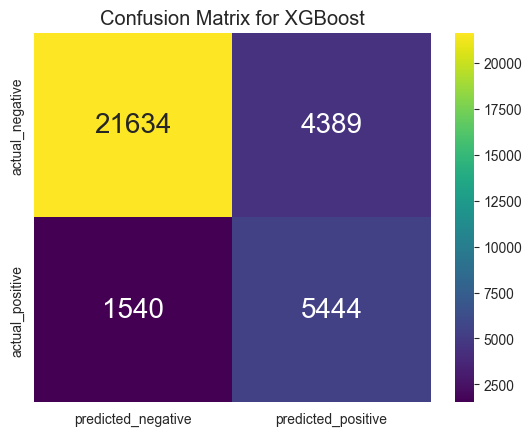

<Figure size 640x480 with 0 Axes>

[[21634  4389]
 [ 1540  5444]]




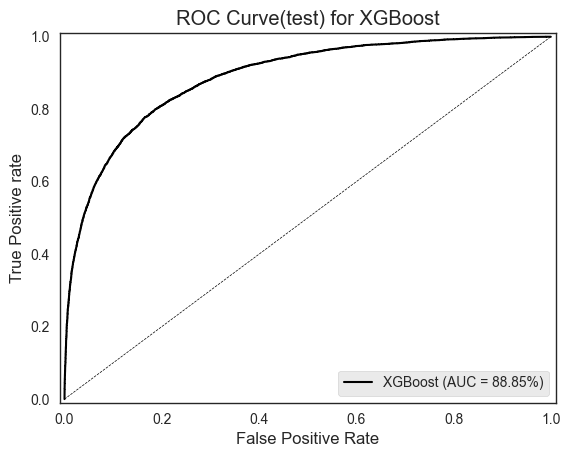

None


Random Forest
Train Accuracy : 83.07%
Test Accuracy : 81.92%
Train Precision : 57.01%
Test Precision : 55.17%
Train Recall : 81.26%
Test Recall : 77.61%
Train F1-Score : 67.01%
Test F1-Score : 64.49%
Train ROC-AUC : 90.53%
Test ROC-AUC : 88.49%


----------------------------------------------------------------------------------------------------
Train Report
               precision    recall  f1-score   support

         0.0       0.94      0.84      0.89    104090
         1.0       0.57      0.81      0.67     27937

    accuracy                           0.83    132027
   macro avg       0.76      0.82      0.78    132027
weighted avg       0.86      0.83      0.84    132027

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Test Report
               precision    recall  f1-score   support

         0.0       0.93      0.83 

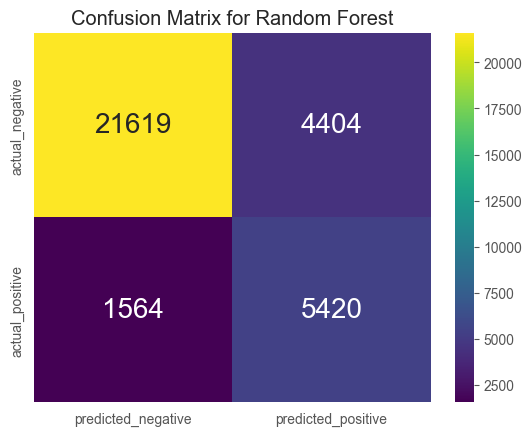

<Figure size 640x480 with 0 Axes>

[[21619  4404]
 [ 1564  5420]]




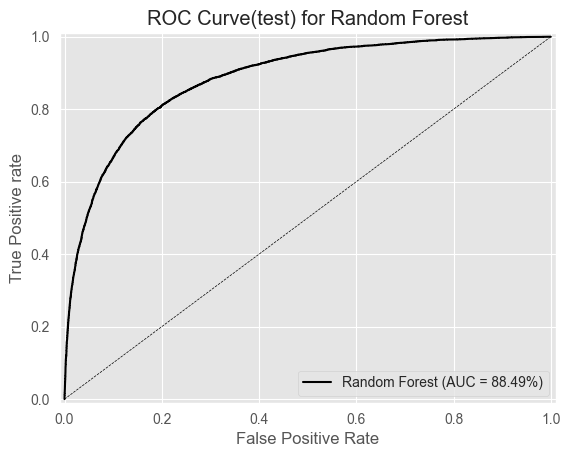

None


Logistic Regression
Train Accuracy : 75.46%
Test Accuracy : 75.44%
Train Precision : 45.14%
Test Precision : 45.09%
Train Recall : 74.19%
Test Recall : 73.70%
Train F1-Score : 56.13%
Test F1-Score : 55.95%
Train ROC-AUC : 82.50%
Test ROC-AUC : 82.20%


----------------------------------------------------------------------------------------------------
Train Report
               precision    recall  f1-score   support

         0.0       0.92      0.76      0.83    104090
         1.0       0.45      0.74      0.56     27937

    accuracy                           0.75    132027
   macro avg       0.68      0.75      0.70    132027
weighted avg       0.82      0.75      0.77    132027

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Test Report
               precision    recall  f1-score   support

         0.0       0.91     

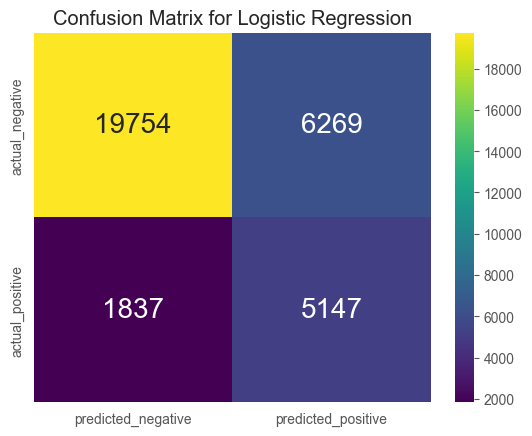

<Figure size 640x480 with 0 Axes>

[[19754  6269]
 [ 1837  5147]]




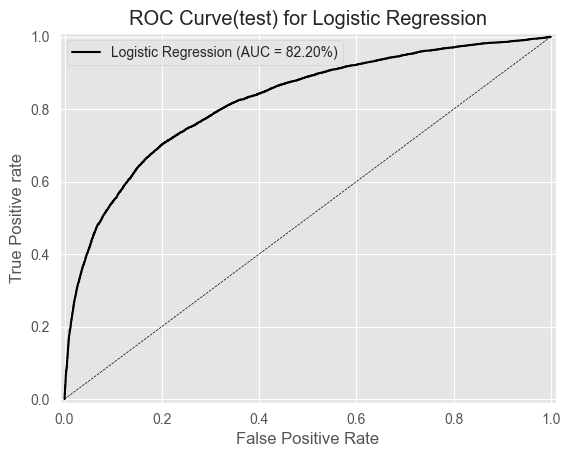

None




In [695]:
for name, model in models:
    
    classifier = model

    classifier.fit(X_train_scaled,y_train)
    
    # y_train1 = np.array(y_train).reshape((-1,1))
    # y_test1 = np.array(y_test).reshape((-1,1))

    y_train_pred=classifier.predict(X_train_scaled)
    y_pred=classifier.predict(X_test_scaled)
    y_pred_prob = classifier.predict_proba(X_test_scaled)[:,1]

    train_accuracy = accuracy_score(y_train,y_train_pred)
    test_accuracy = accuracy_score(y_test,y_pred)
    # cv_accuracy = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = 10, scoring='accuracy')

    train_precision = precision_score(y_train,y_train_pred)
    test_precision = precision_score(y_test,y_pred)
    # cv_precision = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = 10, scoring='precision')

    train_recall = recall_score(y_train,y_train_pred)
    test_recall = recall_score(y_test,y_pred)
    # cv_recall = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = 10, scoring='recall')

    train_f1 = f1_score(y_train,y_train_pred)
    test_f1 = f1_score(y_test,y_pred)
    # cv_f1 = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = 10, scoring='f1')

    train_roc_auc = roc_auc_score(y_train,classifier.predict_proba(X_train_scaled)[:,1])
    test_roc_auc = roc_auc_score(y_test,classifier.predict_proba(X_test_scaled)[:,1])

    start = "\033[1m"
    end = "\033[0;0m"
    
    print(start + name + end)
    print('='*30)
    print(f"Train Accuracy : {train_accuracy*100:.2f}%")
    print(f"Test Accuracy : {test_accuracy*100:.2f}%")
    # print(f"CV Test Accuracy : {cv_accuracy.mean()*100:.2f}%")

    print('='*30)
    print(f"Train Precision : {train_precision*100:.2f}%")
    print(f"Test Precision : {test_precision*100:.2f}%")
    # print(f"CV Test Precision : {cv_precision.mean()*100:.2f}%")
    print('='*30)
    
    print(f"Train Recall : {train_recall*100:.2f}%")
    print(f"Test Recall : {test_recall*100:.2f}%")
    # print(f"CV Test Recall : {cv_recall.mean()*100:.2f}%")
    print('='*30)
    
    print(f"Train F1-Score : {train_f1*100:.2f}%")
    print(f"Test F1-Score : {test_f1*100:.2f}%")
    # print(f"CV Test F1-Score : {cv_f1.mean()*100:.2f}%")
    print('='*30)

    # print(f"Train ROC : {roc_auc_score(y_train,classifier.predict_proba(X_train_scaled)[:, 1])*100:.2f}%")
    print(f"Train ROC-AUC : {train_roc_auc*100:.2f}%")
    print(f"Test ROC-AUC : {test_roc_auc*100:.2f}%")
    print('='*30)
    
    print('\n')
    # print("Cross Val Standard Deviation: {:.2f} %".format(accuracies.std()*100))
    print('-'*100)
    print('Train Report''\n',classification_report(y_train,y_train_pred))
    print('-'*100)

    print('-'*100)
    print('Test Report''\n',classification_report(y_test,y_pred))
    print('-'*100)

    print(conf_matrix(y_test,y_pred,name))
    print('\n')

    print(plot_roc(y_test, y_pred_prob, name))
    
    print('\n')
    model_comparison[name]={
                            'Train_Accuracy':train_accuracy,
                            'Test_Accuracy':test_accuracy,
                            # 'CV_Test_Accuracy':cv_accuracy.mean(),
                            'Train_Precision':train_precision,
                            'Test_Precision': test_precision,
                            # 'CV_Test_Precision':cv_precision.mean(),
                            'Train Recall': train_recall,
                            'Test Recall': test_recall,
                            # 'CV_Test_Recall':cv_recall.mean(),
                            'Train F1-Score': train_f1,
                            'Test F1-Score': test_f1,
                            # 'CV_Test_F1-Score':cv_f1.mean(),
                            'Train ROC-AUC': train_roc_auc,
                            'Test ROC-AUC': test_roc_auc,
                            'Params': str(model.get_params())
                            }

In [696]:
def convert_to_numeric(df):
  
  ignore_columns = ['Model', 'Params']
  cols_to_convert = list(df.columns)

  # Convert lists to sets for efficient difference operation
  set1 = set(cols_to_convert)
  set2 = set(ignore_columns)

  # Elements in list1 but not in list2 (using set difference)
  difference = set1 - set2
  not_in_list2 = list(difference)
  not_in_list2

  # # Loop through the columns and convert them to numeric (handling errors)
  for col in not_in_list2:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Coerce errors to NaN
  return df


In [697]:
models_summary = pd.DataFrame(model_comparison).T.reset_index().rename(columns={'index':'Model'})
models_summary = convert_to_numeric(models_summary)
models_summary.sort_values(by = ['Test Recall'], ascending = False, inplace = True)
models_summary

,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score,Train ROC-AUC,Test ROC-AUC,Params
0,XGBoost,0.833852,0.820371,0.575236,0.553646,0.821169,0.779496,0.676546,0.647440,0.910960,0.888523,"{'objective': 'binary:logistic', 'base_score':..."
1,Random Forest,0.830679,0.819190,0.570090,0.551710,0.812578,0.776060,0.670071,0.644931,0.905319,0.884891,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
2,Logistic Regression,0.754626,0.754416,0.451439,0.450858,0.741884,0.736970,0.561315,0.559457,0.824982,0.821970,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."


In [698]:
models_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Model            3 non-null      str    
 1   Train_Accuracy   3 non-null      float64
 2   Test_Accuracy    3 non-null      float64
 3   Train_Precision  3 non-null      float64
 4   Test_Precision   3 non-null      float64
 5   Train Recall     3 non-null      float64
 6   Test Recall      3 non-null      float64
 7   Train F1-Score   3 non-null      float64
 8   Test F1-Score    3 non-null      float64
 9   Train ROC-AUC    3 non-null      float64
 10  Test ROC-AUC     3 non-null      float64
 11  Params           3 non-null      object 
dtypes: float64(10), object(1), str(1)
memory usage: 459.0+ bytes


### Cross Validation

In [699]:
model_comparison2 = {}

In [700]:
for name, model in models:
    
    classifier = model

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    # skf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

    # classifier.fit(X_train_scaled,y_train)

    # y_pred=classifier.predict(X_test_scaled)
    # y_train_pred=classifier.predict(X_train_scaled)


    # cv_accuracy = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = skf, scoring='accuracy')

    # cv_precision = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = skf, scoring='precision')

    cv_recall = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = skf, scoring='recall')

    cv_f1 = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = skf, scoring='f1')

    # cv_roc_auc = cross_val_score(estimator = classifier, X = X_train_scaled, y = y_train, cv = skf, scoring='roc_auc')


    start = "\033[1m"
    end = "\033[0;0m"
    
    print(start + name + end)
    print('='*30)
    # print("Cross Val Accuracy(Mean): {:.2f} %".format(cv_accuracy.mean()*100))
    # print('='*30)
    
    # print("Cross Val Precision(Mean): {:.2f} %".format(cv_precision.mean()*100))
    # print('='*30)
    
    print("Cross Val Recall(Mean): {:.2f} %".format(cv_recall.mean()*100))
    print('='*30)

    print("Cross Val F1(Mean): {:.2f} %".format(cv_f1.mean()*100))
    print('='*30)

    # print("Cross Val ROC-AUC(Mean): {:.2f} %".format(cv_roc_auc.mean()*100))
    # print('='*30)
    print('\n')

    # cv_1 = pd.DataFrame(cv_accuracy)
    # cv_2 = pd.DataFrame(cv_precision)
    # cv_3 = pd.DataFrame(cv_recall)
    # cv_4 = pd.DataFrame(cv_f1)

    # cv_final = pd.concat([cv_1,cv_2,cv_3,cv_4],axis=1).reset_index(drop=True)
    # cv_final['Model'] = name
    # cv_final.columns=['Model','CV_Acc','CV_Prec','CV_Rec','CV_F1']
    # print(cv_final)
    # print('\n')
    
    model_comparison2[name]={
                            # 'CV_Accuracy':cv_accuracy,
                            # 'CV_Precision':cv_precision,
                            'CV_Recall': cv_recall,
                            'CV_F1':cv_f1,
                            # 'CV_ROC-AUC':cv_roc_auc
                            }

XGBoost
Cross Val Recall(Mean): 78.27 %
Cross Val F1(Mean): 64.49 %


Random Forest
Cross Val Recall(Mean): 77.74 %
Cross Val F1(Mean): 64.49 %


Logistic Regression
Cross Val Recall(Mean): 74.17 %
Cross Val F1(Mean): 56.12 %




In [701]:
models_summary2 = pd.DataFrame(model_comparison2).T.reset_index().rename(columns={'index':'Model'})
# models_summary2 = models_summary2.explode(column=[
#                                         'CV_Accuracy',
#                                         'CV_Precision',
#                                         'CV_Recall',
#                                         'CV_F1',
#                                         'CV_ROC-AUC']).reset_index(drop=True)

models_summary2 = models_summary2.explode(column=[
                                        'CV_Recall',
                                        'CV_F1',
                                        ]).reset_index(drop=True)

models_summary2 = convert_to_numeric(models_summary2)
models_summary2

,Model,CV_Recall,CV_F1
0,XGBoost,0.797781,0.648625
1,XGBoost,0.776664,0.644491
2,XGBoost,0.783107,0.640140
3,XGBoost,0.772011,0.641010
4,XGBoost,0.795634,0.654016
5,XGBoost,0.769506,0.633751
6,XGBoost,0.779170,0.639166
7,XGBoost,0.788758,0.653418
8,XGBoost,0.776942,0.648342
9,XGBoost,0.786967,0.646376


In [702]:
models_summary2.to_csv('Cross Validation.csv')

#### Model Selection 

- Best Metric: <b> Recall </b> to avoid large False Negatives (Missing Customers Who Actually Churn).

    - Here's an analogy to further clarify: Imagine a net designed to catch fish (churning customers). False negatives are the fish that swim through the holes in the net (model's errors) and escape undetected.

- Based on the results of Model Comparison and Cross Validation we arrive at the below:
    - <b> Best Model: </b> Xgboost

<a id='understand-class'></a>
### Understanding the Key Drivers
[Back to top](#back-to-top) <br>

- Now that we have our best model, let's try to understand the key drivers/variables that impact our churn classification model
- Take note that you still need to confirm with your domain knowledge whether this analysis makes sense

In [703]:
# Prepares a default instance of the XGboost Classifier
best_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",       # focus on precision-recall
    scale_pos_weight=3.7,
    max_depth=6,
    learning_rate=0.1,         # same as eta
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=200           # number of boosting rounds
)
# Fits the model on the data
best_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [704]:
# Prepares a default instance of the XGboost Classifier
best_model2 = ensemble.RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42)

# Fits the model on the data
best_model2.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [705]:
# #Create a csv file for each data split just in case

variable_list = [X_train, X_test, y_train, y_test,X_train_scaled,X_test_scaled]

X_train.to_csv('X_train.csv',index=True)
X_test.to_csv('X_test.csv',index=True)
y_train.to_csv('y_train.csv',index=True)
y_test.to_csv('y_test.csv',index=True)
X_train_scaled.to_csv('X_train_scaled.csv',index=True)
X_test_scaled.to_csv('X_test_scaled.csv',index=True)


In [706]:
import pickle
import os

# Define the folder and filename
folder_path = path + '\\models'
file_name = 'XgBoostClassifier_Model.pkl'
full_path = os.path.join(folder_path, file_name)

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Save the trained model object, not the string
with open(full_path, 'wb') as file:
    pickle.dump(best_model, file)


In [707]:
# Define the folder and filename
folder_path = path + '\\models'
file_name = 'RFClassifier_Model.pkl'
full_path = os.path.join(folder_path, file_name)

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Save the trained model object, not the string
with open(full_path, 'wb') as file:
    pickle.dump(best_model2, file)

In [708]:
# Define the folder and filename
folder_path = path + '\\models'
file_name = 'RobustScaler.pkl'
full_path = os.path.join(folder_path, file_name)

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Save the trained model object, not the string
with open(full_path, 'wb') as file:
    pickle.dump(scaler, file)

In [709]:
# X_test_scaled.to_csv('X_test_scaled.csv')
model_path = r"C:\Users\DELL\Downloads\Personal_Projects\Classification_Customer_Churn\models\XgBoostClassifier_Model.pkl"
X_test_scaled2 = pd.read_csv(r"C:\Users\DELL\Downloads\Personal_Projects\Classification_Customer_Churn\notebooks\X_test_scaled.csv")
X_test2 = pd.read_csv(r"C:\Users\DELL\Downloads\Personal_Projects\Classification_Customer_Churn\notebooks\X_test.csv")
y_test2 = pd.read_csv(r"C:\Users\DELL\Downloads\Personal_Projects\Classification_Customer_Churn\notebooks\y_test.csv")

with open(model_path, "rb") as file:
    model = pickle.load(file)

features_to_use = [col for col in X_test_scaled2.columns if col not in ['id', 'Surname','CustomerId','Churn']]

# Predict using the filtered list view

# Now you can use the model
y_pred = model.predict(X_test_scaled2[features_to_use])
X_test2["predictions"] = y_pred
X_test2["actual"] = y_test2['Churn']

# print(X_test2.head(100))
X_test2.to_csv('X_test2.csv',index=False)


from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test2["Churn"], y_pred))
print(classification_report(y_test, y_pred))


[[21634  4389]
 [ 1540  5444]]
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     26023
         1.0       0.55      0.78      0.65      6984

    accuracy                           0.82     33007
   macro avg       0.74      0.81      0.76     33007
weighted avg       0.85      0.82      0.83     33007



In [710]:
import shap
# Fits the explainer
explainer = shap.Explainer(best_model,X_test_scaled)
# explainer = shap.TreeExplainer(best_model,X_test_scaled)

# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test_scaled)

100%|===================| 32943/33007 [05:30<00:00]        

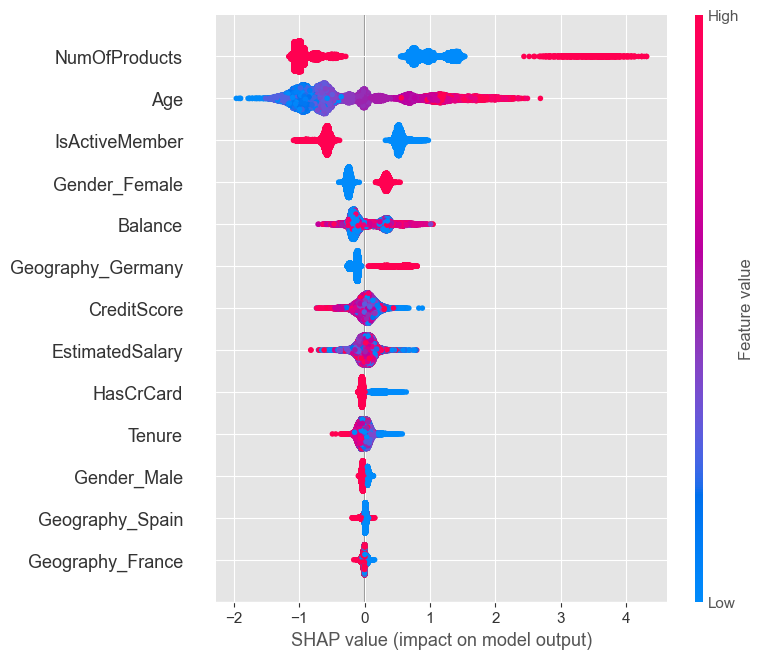

In [711]:
shap.summary_plot(shap_values, X_test_scaled,max_display=100)

<!-- - Guidelines on interpretation:

    - <b>Magnitude:</b> The higher the magnitude, the higher the impact of a feature on the prediction.

    - <b>Direction / sign:</b> 
        - If going to positive X-axis, then values(red/blue or higher/lower) of that feature are moving the predictions to Class 1(Churn) 
        - If going to negative X-axis, then values(red/blue or higher/lower) of that feature are moving the predictions to Class 0(Non-Churn)  -->

This is a SHAP (SHapley Additive exPlanations) summary plot, which visualizes feature importance and their impact on a machine learning model's predictions.

## How to Read This Plot

* Y-Axis (Features): Ordered from top to bottom by importance. NumOfProducts is the most important feature; Geography_France is the least.
* X-Axis (SHAP Value): Indicates the directional impact. Positive values shift the model's output higher, while negative values shift it lower.
* Color Scale (Feature Value): Red dots represent high values of that feature, while blue dots represent low values.

## Key Insights from the Top Features

* NumOfProducts: Very high values (red) strongly push the prediction to the right (positive SHAP). Mid-to-low values (blue/purple) pull it to the left or remain neutral.
* Age: Higher ages (red) consistently push the SHAP value to the positive side. Younger ages (blue) push it significantly to the negative side (down to -2).
* IsActiveMember: Being an active member (high value/red) reduces the prediction score (negative SHAP), whereas inactive members (blue) increase it.
* Gender_Female: Female indicators (red) shift predictions to the positive side, while non-female (blue) shifts it slightly negative.




<a id='conclusion'></a>
### Conclusion
[Back to top](#back-to-top) <br>

<!-- With all the steps mentioned above, the following can be concluded: <br>
1) The customers that churn are mainly influenced by:
    - Age - as customers start to get older it seems they are more likely to churn
       -  A larger positive SHAP value (+4) indicates a stronger push towards a positive prediction compared to a negative value (-2). However, it doesn't always guarantee a positive prediction (Churn).
       
    - The rest of the feature seems to have mixed impact as they have overlapping values, this may indicated a complex and
    non-linear relation ship with the target variable.

    - Imagine a model predicting house prices based on square footage (variable).

        - Linear relationship (not complex): 
            - Every additional square foot increases the predicted price by a constant amount, regardless of the starting size of the house.
        
        - Non-linear relationship (potentially complex):
    
            - As square footage increases, the price might increase more rapidly for larger houses (curved line).
            There might be a threshold where houses above a certain size see a diminishing return on investment (flat line or even a decrease).
    
            - The impact of square footage on price could be stronger in certain locations (interaction with another feature).


 
2) Baseline model (XGB) is performing with a test recall/sensitivity of 73%. 
    - The recall is the measure of our model correctly identifying True Positives. Thus, for all the customers who actually churned, recall tells us how many we correctly identified as customer churns.
    - It means for every 100 customers churning, we are able to correctly identify 73 of them.


3) In line with these findings, the following are recommended:
    - Add new features that are more relevant to customer churn, or maybe create new features (Feature Engineering)
    - Combine other classification models to improve Recall(Ensemble i.e. 'VotingClassifier')
    - Split the data into different subgroups, then create a model for each subgroup, as maybe this can improve the models predictive capability -->

Based on standard behavior in bank churn models (where a positive SHAP value increases the probability of a customer leaving), this chart outlines the exact profile of high-risk versus low-risk customers.
## 🔴 High Churn Risk Factors (Positive SHAP Values)

* High Number of Products: Customers holding a high number of products (red dots at +3 to +4) have an extremely high risk of churning.
* Older Age: Older customers (red dots pushing past +1) show a significantly higher likelihood to churn compared to younger ones.
* Inactive Status: Inactive members (blue dots on the positive side) are much more likely to leave the bank.
* Female Gender: Female customers (Gender_Female = red) lean slightly toward a higher churn risk.
* Location (Germany): Customers based in Germany (Geography_Germany = red) exhibit a higher tendency to churn.

## 🔵 Low Churn Risk Factors (Negative SHAP Values)

* Younger Age: Younger customers (blue dots stretching down to -2) are the most stable and least likely to churn.
* Active Status: Active members (IsActiveMember = red) are heavily pushed toward the negative side, meaning they have high retention.
* Moderate/Low Product Count: Customers with fewer, optimal products (blue dots clustered around -1) are less likely to leave.

## Summary Profile

* Highest Retention Profile: A young, active member with a low/optimal number of products.
* Highest Churn Risk Profile: An older, inactive customer with a high number of products, potentially located in Germany.

Would you like to explore targeted retention strategies for the high-risk customer segments identified here?



To combat churn effectively using the data from your model, you should deploy targeted, proactive retention strategies tailored to the highest-risk behaviors highlighted in the SHAP plot.
## 📦 1. High Number of Products (NumOfProducts)

* The Problem: In banking datasets, customers with 3 or 4 products [typically show a staggering near-100% churn rate](https://www.kaggle.com/code/adeolaadesina/predicting-bank-customer-churn) because they are often victims of aggressive "over-selling" or algorithmic bundle mismatches rather than true engagement.
* Strategy: Implement an Account Consolidation Campaign. Reach out to customers holding 3+ products for an "account health checkup." Audit their products to see if they are paying duplicate fees. Downsize them into a single, high-value comprehensive tier if they are experiencing fee fatigue.

## 👥 2. Older Age Group (Age)

* The Problem: The SHAP plot indicates a sharp compounding churn risk for older demographics. [Studies on this specific dataset type](https://medium.com/@ctedyanto/bank-customer-churn-analysis-identifying-key-drivers-of-customer-attrition-d9a0994bd08e) show that customers aged 50+ exhibit the highest churn spikes, particularly when digital experiences alienate them.
* Strategy: Launch dedicated Wealth Management & Legacy Services. Transition older accounts from standard transaction-based checking/savings into high-yield certificates of deposit (CDs), retirement planning, or family trust accounts to increase structural stickiness.

## 💤 3. Inactive Status (IsActiveMember)

* The Problem: Inactivity is universally the strongest operational predictor of a customer leaving.
* Strategy: Establish an Automated Re-engagement Funnel.
* Set up a trigger: if there are zero logged sessions or card swipes within 45 days, auto-generate a high-value nudge.
   * Offer incentives like cash-back multipliers for the next three transactions or a waived monthly fee if they set up a new recurring automated clearing house (ACH) transfer or utility autopay.

## 🇩🇪 4. German Geography (Geography_Germany)

* The Problem: German clients have a visibly higher localized push toward churn than Spanish or French clients. This usually indicates a localized competitive disadvantage (e.g., a regional competitor offering better rates or localized customer support failure).
* Strategy: Conduct a Regional Competitive Analysis & Product Localization. Focus marketing and local branch efforts in Germany on matching competitor interest rates. Review the localized mobile app experience and ensure communications align with regional expectations.

## 👩 5. Female Demographics (Gender_Female)

* The Problem: Female customers skew noticeably toward the positive risk side compared to male counterparts.
* Strategy: Create targeted financial empowerment and wellness programs tailored around long-term security, business growth, or family savings. Use focused focus groups to see if customer service or marketing channels are unintentionally introducing gender-biased friction.
